In [17]:
import networkx as nx
import time

# 1. Carregando o grafo original
print("Carregando o grafo...")

# Lendo como direcionado inicialmente
G_original = nx.read_edgelist('p2p-Gnutella05.txt', create_using=nx.DiGraph(), nodetype=int)

############ Fase 1 #############
# 2. Limpeza de Dados
# Remove auto-loops
G_original.remove_edges_from(nx.selfloop_edges(G_original))

# Para a análise de Diâmetro, Raio e Caminhos, o padrão é tratar como não-direcionado
G_nao_direcionado = G_original.to_undirected()

# Encontra a Maior Componente Conexa
componentes = sorted(nx.connected_components(G_nao_direcionado), key=len, reverse=True)
maior_componente_nos = componentes[0]

# Cria o subgrafo final limpo que usaremos no resto do trabalho
G = G_nao_direcionado.subgraph(maior_componente_nos).copy()

# Grafo Original Limpo (Para calcular a Densidade)
G_original_limpo = G_original.copy()
G_original_limpo.remove_edges_from(nx.selfloop_edges(G_original_limpo))

print("-" * 40)

# Dados já disponíveis no SNAP
print(f"GRAFO ORIGINAL: {G_original.number_of_nodes()} nós | {G_original.number_of_edges()} arestas.")

print(f"GRAFO ORIGINAL LIMPO (Sem auto-loop): {G_original_limpo.number_of_nodes()} nós | {G_original_limpo.number_of_edges()} arestas.")
print(f"GRAFO LIMPO (Componente Gigante): {G.number_of_nodes()} nós | {G.number_of_edges()} arestas.")
print("-" * 40)

############ Fase 2 #############
# 3. Métricas Básicas
graus = dict(G.degree())
valores_graus = list(graus.values())

densidade_global = nx.density(G_original_limpo)

# Componente Gigante (O subgrafo que criamos antes)
densidade_gigante = nx.density(G)

print("\n--- MÉTRICAS TOPOLÓGICAS ---")
print(f"Grau Mínimo: {min(valores_graus)}")
print(f"Grau Máximo: {max(valores_graus)}")
print(f"Grau Médio: {sum(valores_graus) / len(valores_graus):.2f}")
print(f"Densidade da Rede Global: {densidade_global:.6f}")
print(f"Densidade do Núcleo (Comp. Gigante): {densidade_gigante:.6f}")

# Dados já disponíveis no SNAP
# Clusterização e Triângulos
#print(f"Coef. de Clusterização Médio: {nx.average_clustering(G):.4f}")
#total_triangulos = sum(nx.triangles(G).values()) / 3
#print(f"Número de Triângulos: {int(total_triangulos)}")

# 4. Métricas Computacionalmente Pesadas
# ATENÇÃO: O cálculo exato do diâmetro e raio em 8.800 nós é O(V(V+E))
# Pode levar de 1 a 15 minutos rodando no seu computador.
# print("\nCalculando Diâmetro e Raio... (Pode demorar alguns minutos. Pegue um café)")
# inicio = time.time()

#diametro = nx.diameter(G)
#raio = nx.radius(G)
#comprimento_medio = nx.average_shortest_path_length(G)

#fim = time.time()

#print(f"Diâmetro: {diametro}")
#print(f"Raio: {raio}")
#print(f"Comprimento Médio dos Caminhos: {comprimento_medio:.2f}")
#print(f"Tempo de processamento dessas 3 medidas: {fim - inicio:.2f} segundos")

Carregando o grafo...
----------------------------------------
GRAFO ORIGINAL: 8846 nós | 31839 arestas.
GRAFO ORIGINAL LIMPO (Sem auto-loop): 8846 nós | 31839 arestas.
GRAFO LIMPO (Componente Gigante): 8842 nós | 31837 arestas.
----------------------------------------

--- MÉTRICAS TOPOLÓGICAS ---
Grau Mínimo: 1
Grau Máximo: 88
Grau Médio: 7.20
Densidade da Rede Global: 0.000407
Densidade do Núcleo (Comp. Gigante): 0.000815


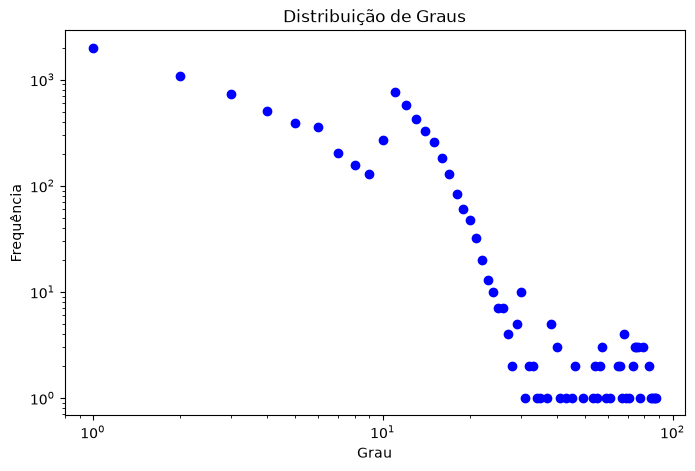

In [18]:
import collections
import matplotlib.pyplot as plt
contagem_graus = collections.Counter(valores_graus)
graus, frequencia = zip(*contagem_graus.items())

plt.figure(figsize=(8, 5))
plt.loglog(graus, frequencia, 'bo')
plt.title("Distribuição de Graus")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.savefig("distribuicao_graus.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
num_scc = nx.number_strongly_connected_components(G_original)
num_wcc = nx.number_weakly_connected_components(G_original)

print(f"Número total de Componentes Fortemente Conexas: {num_scc}")
print(f"Número total de Componentes Conexas: {num_wcc}")

Número total de Componentes Fortemente Conexas: 5613
Número total de Componentes Conexas: 3


O Hub escolhido é o nó 842, que possui 88 conexões.


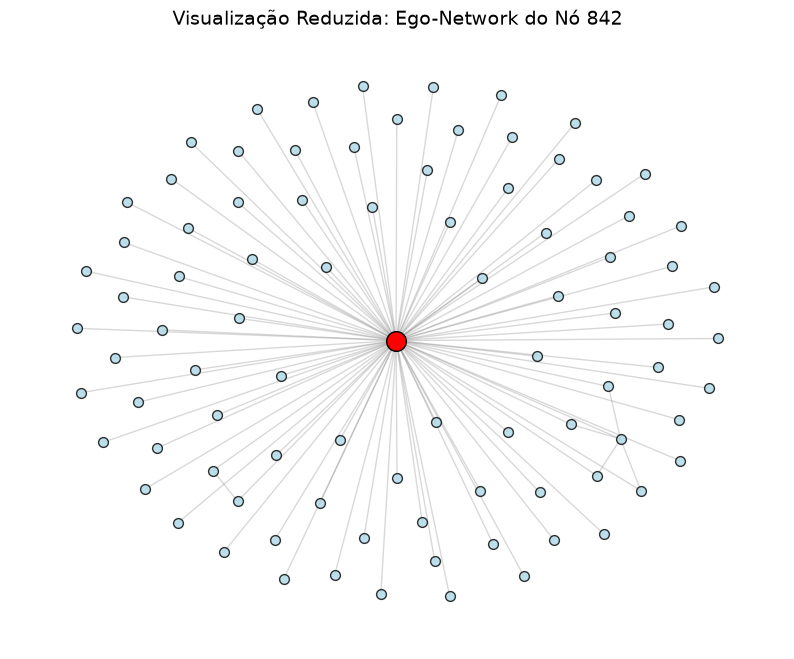

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Encontrar o nó mais conectado (Hub) dentro do grafo limpo (G)
graus = dict(G.degree())
no_hub = max(graus, key=graus.get)
grau_do_hub = graus[no_hub]

print(f"O Hub escolhido é o nó {no_hub}, que possui {grau_do_hub} conexões.")

# 2. Criar a Ego-Network (O subgrafo reduzido)
# Pegamos todos os vizinhos do Hub
vizinhos = list(G.neighbors(no_hub))
vizinhos.append(no_hub)

# Criamos um subgrafo contendo apenas esses nós
G_reduzido = G.subgraph(vizinhos)

# 3. Configurar o desenho do gráfico
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_reduzido, seed=42) 

nx.draw_networkx_nodes(G_reduzido, pos, 
                       node_size=50, 
                       node_color="lightblue", 
                       edgecolors="black",
                       alpha=0.8)

nx.draw_networkx_nodes(G_reduzido, pos, 
                       nodelist=[no_hub], 
                       node_size=200, 
                       node_color="red", 
                       edgecolors="black")

nx.draw_networkx_edges(G_reduzido, pos, 
                       alpha=0.3, 
                       edge_color="gray")

plt.title(f"Visualização Reduzida: Ego-Network do Nó {no_hub}", fontsize=14)
plt.axis("off")

plt.savefig("visualizacao_grafo.png", dpi=300, bbox_inches="tight")

plt.show()

O K-Core tem 112 nós. Desenhando...


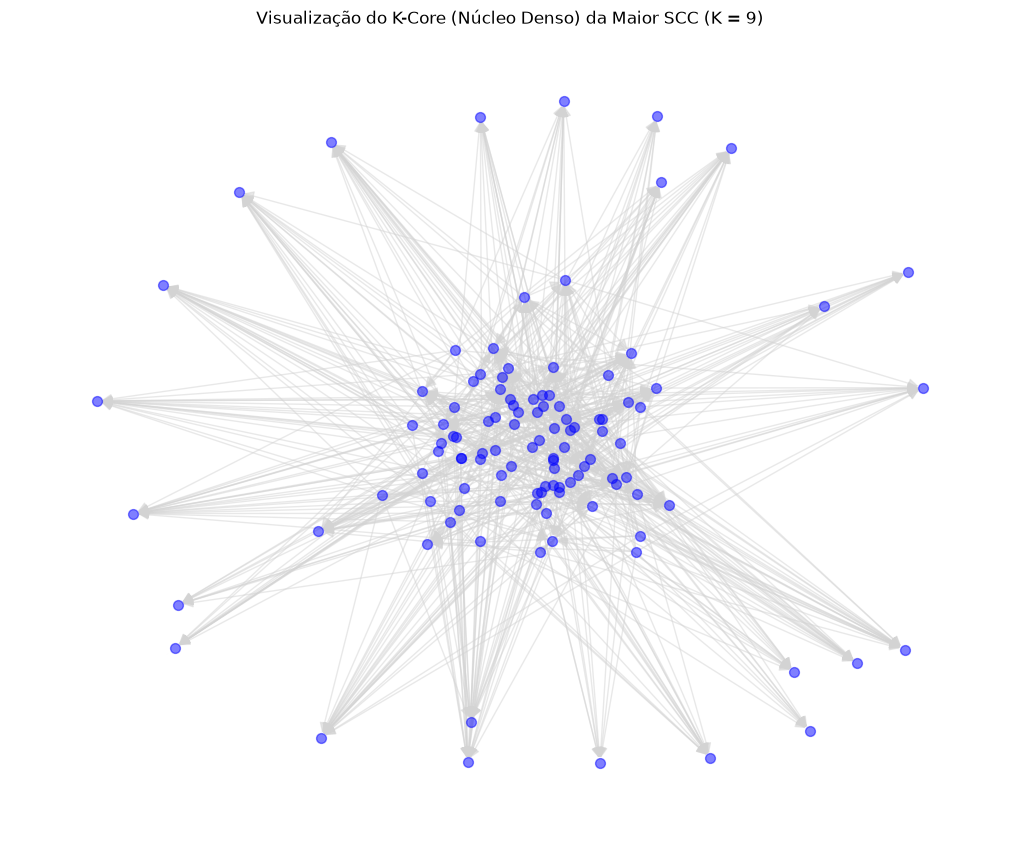

In [21]:
# G_maior_scc é o subgrafo da maior SCC
# Extrai o núcleo onde todos os nós têm pelo menos 10 conexões entre si
G_maior_scc = G_original_limpo.subgraph(maior_scc_nos).copy()
k_core = nx.k_core(G_maior_scc, k=9) 

print(f"O K-Core tem {k_core.number_of_nodes()} nós. Desenhando...")

# Como o número de nós cai drasticamente, o desenho é rápido!
plt.figure(figsize=(10, 8))
nx.draw(k_core, 
        node_size=50, 
        node_color="blue", 
        edge_color="lightgray",
        arrowsize=15,
        alpha=0.5)
plt.title("Visualização do K-Core (Núcleo Denso) da Maior SCC (K = 9)")
plt.show()

In [22]:
import networkx as nx
import time
import numpy as np
import scipy.stats as st

# 1. PREPARAÇÃO DOS GRAFOS PARA OS TESTES
print("Preparando grafos e estruturas para os algoritmos...")

# Grafo Direcionado (Necessário para o Tarjan)
G_dir = G_original_limpo.copy()

# Grafo Não-Direcionado (Componente Gigante) para BFS, DFS, Dijkstra, MST, Euleriano
G_undir = G.copy()

# Para o Floyd-Warshall (O(V^3)), precisamos de uma amostra pequena para não travar o PC
# Vamos pegar a Ego-Network (vizinhança de distância 1) do Hub
no_hub = max(dict(G_undir.degree()).items(), key=lambda x: x[1])[0]
G_amostra_fw = nx.ego_graph(G_undir, no_hub, radius=1)

print(f"Grafo Base: {G_undir.number_of_nodes()} nós | Amostra Floyd-Warshall: {G_amostra_fw.number_of_nodes()} nós\n")


# 2. MÁQUINA DE BENCHMARK COM ESTATÍSTICA EXATA
def benchmark_algoritmo(nome, funcao, *args, repeticoes=30, **kwargs):
    tempos = []
    
    print(f"--- Testando: {nome} ---")
    for _ in range(repeticoes):
        inicio = time.time()
        
        # Executa a função
        resultado = funcao(*args, **kwargs)
        
        # Se for um gerador (como BFS/DFS), força a execução até o fim
        if type(resultado).__name__ == 'generator':
            list(resultado)
            
        fim = time.time()
        tempos.append(fim - inicio)
    
    # Cálculos Estatísticos
    media = np.mean(tempos)
    desvio_padrao = np.std(tempos, ddof=1)
    erro_padrao = desvio_padrao / np.sqrt(repeticoes)
    
    # REGRA DA TABELA:
    if repeticoes >= 30:
        # n >= 30: Distribuição Normal (Z)
        ic = st.norm.interval(0.95, loc=media, scale=erro_padrao)
        dist_usada = "Normal (Z)"
    else:
        # n < 30: Distribuição t-Student
        ic = st.t.interval(0.95, df=repeticoes-1, loc=media, scale=erro_padrao)
        dist_usada = "t-Student"
        
    print(f"Média: {media:.5f}s | Desvio Padrão: {desvio_padrao:.5f}s")
    print(f"IC 95% [{dist_usada}]: [{ic[0]:.5f}, {ic[1]:.5f}]\n")


# 3. EXECUÇÃO DOS ALGORITMOS DA DISCIPLINA

# 1. Busca em Largura (BFS) - O(V + E)
benchmark_algoritmo("Busca em Largura (BFS)", nx.bfs_edges, G_undir, no_hub, repeticoes=30)

# 2. Busca em Profundidade (DFS) - O(V + E)
benchmark_algoritmo("Busca em Profundidade (DFS)", nx.dfs_edges, G_undir, no_hub, repeticoes=30)

# 3. Verificação de Eulerianidade - O(V + E)
# Checa se todos os nós têm grau par para existir um ciclo Euleriano
benchmark_algoritmo("Verificação de Eulerianidade", nx.is_eulerian, G_undir, repeticoes=30)

# 4. Dijkstra (Caminho Mínimo Origem-Única) - O((V+E) log V)
benchmark_algoritmo("Dijkstra", nx.single_source_dijkstra_path_length, G_undir, no_hub, repeticoes=30)

# 5. Floyd-Warshall (Todos para Todos) - O(V^3)
# ATENÇÃO: Rodando apenas na G_amostra_fw para ser viável!
benchmark_algoritmo("Floyd-Warshall (Na Amostra Reduzida)", nx.floyd_warshall, G_amostra_fw, repeticoes=30)

# 6. Algoritmo de Tarjan (Componentes Fortemente Conexas) - O(V + E)
# OBS: O NetworkX usa Tarjan por baixo dos panos na função strongly_connected_components
benchmark_algoritmo("Tarjan (SCC no Grafo Direcionado)", nx.strongly_connected_components, G_dir, repeticoes=30)

# 7. Árvore Geradora Mínima (Prim) - O((V+E) log V)
benchmark_algoritmo("MST - Algoritmo de Prim", nx.minimum_spanning_tree, G_undir, algorithm='prim', repeticoes=30)

# 8. Árvore Geradora Mínima (Kruskal) - O(E log E)
benchmark_algoritmo("MST - Algoritmo de Kruskal", nx.minimum_spanning_tree, G_undir, algorithm='kruskal', repeticoes=30)

print("Fim dos testes")

Preparando grafos e estruturas para os algoritmos...
Grafo Base: 8842 nós | Amostra Floyd-Warshall: 89 nós

--- Testando: Busca em Largura (BFS) ---
Média: 0.01126s | Desvio Padrão: 0.01124s
IC 95% [Normal (Z)]: [0.00724, 0.01529]

--- Testando: Busca em Profundidade (DFS) ---
Média: 0.01258s | Desvio Padrão: 0.01129s
IC 95% [Normal (Z)]: [0.00854, 0.01662]

--- Testando: Verificação de Eulerianidade ---
Média: 0.00000s | Desvio Padrão: 0.00000s
IC 95% [Normal (Z)]: [0.00000, 0.00000]

--- Testando: Dijkstra ---
Média: 0.02222s | Desvio Padrão: 0.00186s
IC 95% [Normal (Z)]: [0.02156, 0.02289]

--- Testando: Floyd-Warshall (Na Amostra Reduzida) ---
Média: 0.06268s | Desvio Padrão: 0.00170s
IC 95% [Normal (Z)]: [0.06208, 0.06329]

--- Testando: Tarjan (SCC no Grafo Direcionado) ---
Média: 0.01744s | Desvio Padrão: 0.00200s
IC 95% [Normal (Z)]: [0.01673, 0.01816]

--- Testando: MST - Algoritmo de Prim ---
Média: 0.07998s | Desvio Padrão: 0.01845s
IC 95% [Normal (Z)]: [0.07338, 0.08658]

-

In [23]:
import networkx as nx
import random

# Usa a Maior Componente Conexa Não-Direcionada (criada na Fase 1)
# G = o grafo limpo

N = G.number_of_nodes()
E = G.number_of_edges()

print("="*50)
print("1. TESTE DE MUNDO PEQUENO (SMALL-WORLD)")
print("="*50)
# Calcula probabilidade p para o Grafo Aleatório (Erdos-Renyi)
# p = (2 * Arestas) / (Nós * (Nós - 1))
p = (2 * E) / (N * (N - 1))

# Gera o Grafo Aleatório
G_aleat = nx.erdos_renyi_graph(N, p, seed=42)

# Assegura que usamos a maior componente do grafo aleatório para calcular L
comp_aleat = sorted(nx.connected_components(G_aleat), key=len, reverse=True)[0]
G_aleat_gigante = G_aleat.subgraph(comp_aleat)

C_real = nx.average_clustering(G)
C_aleat = nx.average_clustering(G_aleat_gigante)

print(f"Clustering Real (C): {C_real:.6f}")
print(f"Clustering Aleatório (C_aleat): {C_aleat:.6f}")
print("-> Como C_real >> C_aleat, a rede tem aglomeração forte (Small-World)!\n")

print("="*50)
print("3. TESTE DE ROBUSTEZ (ATAQUES)")
print("="*50)

# Quantidade de nós a remover (5%)
cinco_porcento = int(N * 0.05)
print(f"Tamanho original do Componente Gigante: {N} nós.")
print(f"Vamos remover {cinco_porcento} nós (5%) em ambos os cenários.\n")

# --- CENÁRIO A: Falha Aleatória ---
G_aleatorio = G.copy()
nos_para_remover = random.sample(list(G_aleatorio.nodes()), cinco_porcento)
G_aleatorio.remove_nodes_from(nos_para_remover)

# Mede o que sobrou
comp_pos_aleatorio = sorted(nx.connected_components(G_aleatorio), key=len, reverse=True)[0]
tamanho_pos_aleat = len(comp_pos_aleatorio)
percentagem_aleat = (tamanho_pos_aleat / N) * 100

print(f"CENÁRIO A (Aleatório): O Componente Gigante caiu para {tamanho_pos_aleat} nós.")
print(f"-> A rede manteve {percentagem_aleat:.1f}% da sua estrutura.\n")


# --- CENÁRIO B: Ataque Direcionado aos Hubs ---
G_ataque = G.copy()
# Ordena os nós pelo grau, do maior para o menor
hubs = sorted(G_ataque.degree(), key=lambda x: x[1], reverse=True)
# Pega apenas os IDs dos top 5% Hubs
top_hubs_ids = [no for no, grau in hubs[:cinco_porcento]]

G_ataque.remove_nodes_from(top_hubs_ids)

# Mede o que sobrou
comp_pos_ataque = sorted(nx.connected_components(G_ataque), key=len, reverse=True)[0]
tamanho_pos_ataque = len(comp_pos_ataque)
percentagem_ataque = (tamanho_pos_ataque / N) * 100

print(f"CENÁRIO B (Ataque a Hubs): O Componente Gigante colapsou para {tamanho_pos_ataque} nós.")
print(f"-> A rede manteve apenas {percentagem_ataque:.1f}% da sua estrutura.")

1. TESTE DE MUNDO PEQUENO (SMALL-WORLD)
Clustering Real (C): 0.007204
Clustering Aleatório (C_aleat): 0.000869
-> Como C_real >> C_aleat, a rede tem aglomeração forte (Small-World)!

3. TESTE DE ROBUSTEZ (ATAQUES)
Tamanho original do Componente Gigante: 8842 nós.
Vamos remover 442 nós (5%) em ambos os cenários.

CENÁRIO A (Aleatório): O Componente Gigante caiu para 8330 nós.
-> A rede manteve 94.2% da sua estrutura.

CENÁRIO B (Ataque a Hubs): O Componente Gigante colapsou para 8040 nós.
-> A rede manteve apenas 90.9% da sua estrutura.
